# Log Anomaly Detection (BGL Dataset): Deep SVDD Pipeline


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================

import subprocess, sys

def install_packages(packages):
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: may have failed — {result.stderr[:200]}")
        else:
            print("  OK")

install_packages([
    "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn",
    "torch",
    "sentence-transformers",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: torch
  OK
Installing: sentence-transformers
  OK

All packages ready.


  Dataset           : HDFS
  Embedding model   : all-MiniLM-L6-v2
  SVDD hidden dim   : 256
  SVDD repr dim     : 32
  SVDD epochs       : 40
  Warmup epochs     : 5
  Train ratio       : 0.6
  Val ratio         : 0.2
  Test normals      : remaining 20% of normals
  Test anomalies    : ALL available (no cap)
  F-beta            : 0.5
  Device            : cpu
Loading dataset: HDFS
  Loading HDFS block traces ...
    Block traces: 575061, Templates: 29
    After sampling  : 10303 blocks (10000 normal, 303 anomalous)

  Total samples     : 10303
  Normal            : 10000  (97.1%)
  Anomalous         : 303  (2.9%)

  Sample log_text:
    HDFS Block Trace | Receiving blocksrc:dest: -> BLOCK* NameSystemallocateBlock: -> PacketResponderfor blockterminating -> Received blockof sizefrom -> BLOCK* NameSystemaddStoredBlock: blockMap updated:is added tosize -> BLOCK* NameSystemdelete:is added to invalidSet of -> Deleting blockfile
Creating train / validation / test splits ...

  Train  :   6000

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3696.66it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384

Encoding train set (6000 samples) ...


Batches: 100%|██████████| 94/94 [03:09<00:00,  2.01s/it]


Encoding validation set (2000 samples) ...


Batches: 100%|██████████| 32/32 [00:27<00:00,  1.15it/s]


Encoding test set (2303 samples) ...


Batches: 100%|██████████| 36/36 [01:11<00:00,  1.97s/it]



  Train embeddings  : (6000, 384)
  Val embeddings    : (2000, 384)
  Test embeddings   : (2303, 384)
Deep SVDD network: 384 -> 256 -> 256 -> 32 (L2-norm)
Parameters: 173,568
Converting training embeddings to tensor ...
Computing warm-start hypersphere centre ...
  Running 5 warm-up epochs ...
  Centre norm after warmup: 0.1157

Training Deep SVDD for 40 epochs ...
  Epoch   1/40  Loss: 0.810282
  Epoch  10/40  Loss: 0.781929
  Epoch  20/40  Loss: 0.781922
  Epoch  30/40  Loss: 0.781921
  Epoch  40/40  Loss: 0.781919

Training complete.  Final loss: 0.781919
Computing validation-set distances ...
  Val distance stats (normal logs only):
    Min    : 0.7819
    Median : 0.7819
    Max    : 0.7828

  Threshold selection via F-beta (beta=0.5) on validation PR curve:
    Best threshold       : 0.7819
    At threshold         : Precision=1.000  Recall=1.000  F0.5=1.000
    Pseudo-anomaly count : 1006  (top 7% of 2000 val normals)
Scoring test set ...

  EVALUATION  --  Deep SVDD  [HDFS]
  

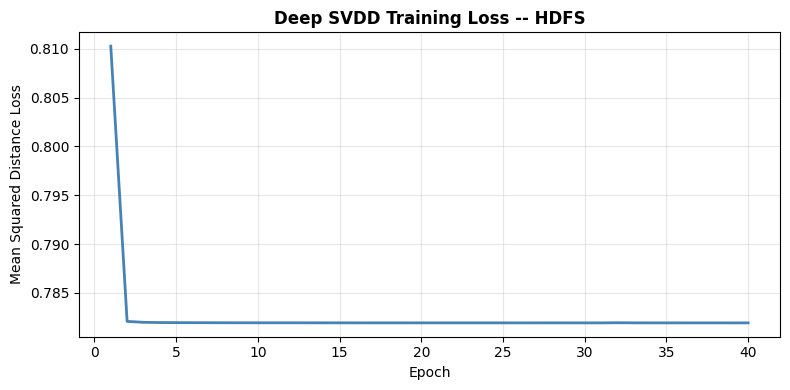

  Saved: hdfs_svdd_training_loss.png


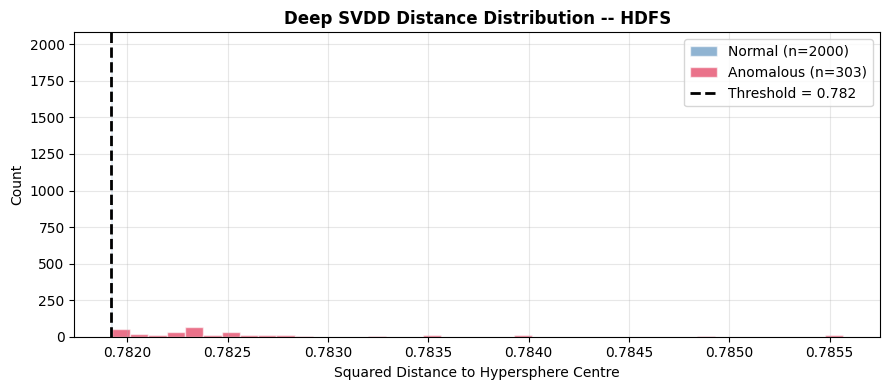

  Saved: hdfs_svdd_distance_dist.png


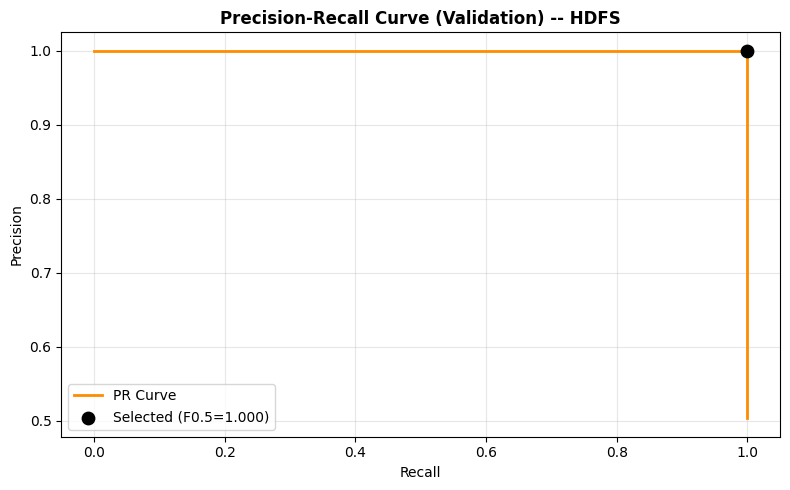

  Saved: hdfs_svdd_pr_curve.png


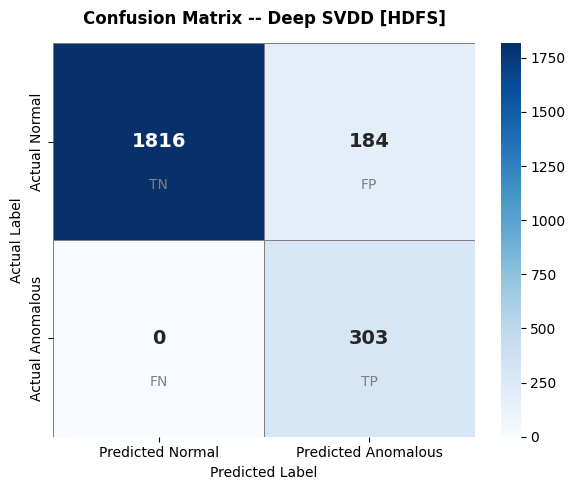

  Saved: hdfs_svdd_confusion_matrix.png


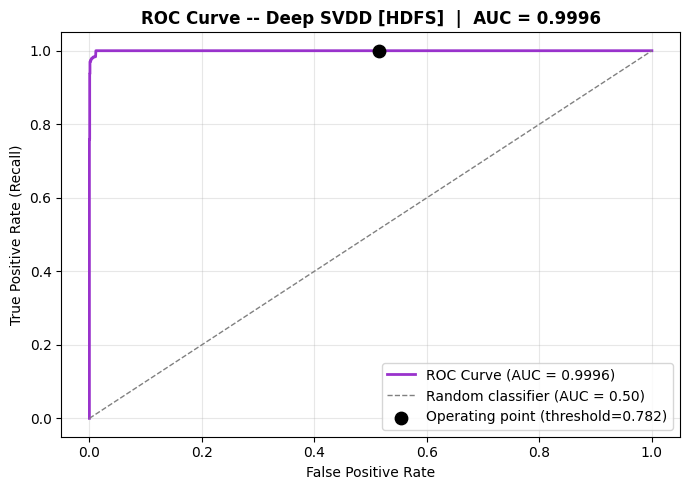

  Saved: hdfs_svdd_roc_curve.png


In [2]:
# =============================================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# =============================================================================

import json, os, re, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Dataset selection ─────────────────────────────────────────────────────────
DATASET = "HDFS"

# ── Dataset-specific configurations ──────────────────────────────────────────

DATASET_CONFIGS = {
    "BGL": {
        "structured_log_path": "../../Datasets/BGL/Sample/BGL_2k.log_structured.csv",
        "templates_path":      "../../Datasets/BGL/Sample/BGL_2k.log_templates.csv",
        # Schema
        "label_col":     "Label",
        "normal_value":  "-",           # '-' = Normal in BGL
        "event_id_col":  "EventId",
        "component_col": "Component",
        "level_col":     "Level",
        "content_col":   "Content",
        "template_col":  "EventTemplate",
        # Sampling: BGL-2k is small (~2k rows), no caps needed
        "normal_sample_cap":  None,
        "anomaly_type_col":   None,
        "anomaly_n_per_type": None,
    },
    "HDFS": {
        "traces_path":    "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/Event_traces.csv",
        "templates_path": "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/HDFS.log_templates.csv",
        # Schema
        "label_col":    "Label",
        "normal_value": "Success",      # 'Success' = Normal, 'Fail' = Anomalous
        "features_col": "Features",     # column holding [E5,E22,...] sequence
        # Sampling caps — evidence-based from full-dataset fingerprint analysis:
        #   558,223 normal blocks have only 365 unique event-sequence fingerprints.
        #   Top 15 fingerprints cover 90%, top 55 cover 99% of all normal blocks.
        #   A 10,000-normal random sample captures all high-frequency patterns,
        #   cutting train size 56x (334,933 -> 6,000) with negligible diversity loss.
        #   Anomaly stratification: 20 samples/type across all 26 types = 303 total,
        #   giving full anomaly-type coverage for reliable evaluation and RAG retrieval.
        "normal_sample_cap":  10000,    # None = use all; 10k covers 99%+ of distribution
        "anomaly_type_col":   "Type",   # column used to stratify anomaly sampling
        "anomaly_n_per_type": 20,       # samples per anomaly type (all 26 types -> ~303 total)
    },
}

# ── Embedding model ───────────────────────────────────────────────────────────
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
EMBED_DIM        = 384   # confirmed after model load

# ── Deep SVDD hyper-parameters ────────────────────────────────────────────────
SVDD_HIDDEN_DIM    = 256
SVDD_REPR_DIM      = 32
SVDD_EPOCHS        = 40
SVDD_LR            = 5e-4
SVDD_BATCH_SIZE    = 64
SVDD_WARMUP_EPOCHS = 5

# ── Split ratios ─────────────────────────────────────────────────────
TRAIN_RATIO = 0.60   # fraction of normal samples for SVDD training
VAL_RATIO   = 0.20   # fraction of normal samples for threshold calibration
TEST_NORMAL_CAP  = 215   # max normal samples in test set
TEST_ANOMALY_CAP = 15    # max anomalous samples in test set

# ── Threshold calibration ─────────────────────────────────────────────────────
PSEUDO_ANOMALY_PERCENTILE = 93   # top 7% of val distances = pseudo-anomalies
FBETA = 0.5                      # beta < 1 weights precision over recall

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"  Dataset           : {DATASET}")
print(f"  Embedding model   : {EMBED_MODEL_NAME}")
print(f"  SVDD hidden dim   : {SVDD_HIDDEN_DIM}")
print(f"  SVDD repr dim     : {SVDD_REPR_DIM}")
print(f"  SVDD epochs       : {SVDD_EPOCHS}")
print(f"  Warmup epochs     : {SVDD_WARMUP_EPOCHS}")
print(f"  Train ratio       : {TRAIN_RATIO}")
print(f"  Val ratio         : {VAL_RATIO}")
print(f"  Test normals      : remaining {1.0 - TRAIN_RATIO - VAL_RATIO:.0%} of normals")
print(f"  Test anomalies    : ALL available (no cap)")
print(f"  F-beta            : {FBETA}")
print(f"  Device            : {device}")


# =============================================================================
# GENERIC DATA LOADING
#
# Output contract (identical for every dataset):
#   log_text     (str)  — enriched text fed to the sentence transformer
#   is_normal    (bool) — True if the sample is labelled Normal
#   binary_label (int)  — 0 = Normal, 1 = Anomalous
#
# BGL  loader : line-level;  one row = one log line
# HDFS loader : block-level; one row = one block trace (event sequence)
# =============================================================================



# ── Dataset-size sampling (applied before log_text construction) ──────────────

def _apply_sampling(df, config, random_seed=42):
    """Apply per-dataset sampling caps to keep dataset size manageable.

    Called inside each loader BEFORE building log_text, so the expensive
    DataFrame.apply(...) step only runs on the sampled rows — not on the
    full 575k HDFS blocks.

    Normal blocks   : random sample up to config["normal_sample_cap"].
    Anomalous blocks: stratified by config["anomaly_type_col"], taking up to
                      config["anomaly_n_per_type"] samples per category.
                      This ensures all anomaly types are represented even at
                      small sample sizes (all 26 HDFS types with just 20/type).
                      Falls back to a flat random cap via "anomaly_sample_cap"
                      when stratification fields are absent.

    For datasets without caps (e.g. BGL-2k), all values are None and this
    function returns df unchanged.

    Args:
        df          : DataFrame with is_normal (bool) already set.
        config      : Per-dataset dict from DATASET_CONFIGS.
        random_seed : For reproducible sampling.

    Returns:
        Sampled (or original) DataFrame with reset index.
    """
    normal_cap    = config.get("normal_sample_cap")
    anom_type_col = config.get("anomaly_type_col")
    n_per_type    = config.get("anomaly_n_per_type")
    anom_cap      = config.get("anomaly_sample_cap")

    df_n = df[df["is_normal"]].copy()
    df_a = df[~df["is_normal"]].copy()

    if normal_cap is not None and len(df_n) > normal_cap:
        df_n = df_n.sample(n=normal_cap, random_state=random_seed)

    if anom_type_col and n_per_type:
        parts = [
            grp.sample(n=min(n_per_type, len(grp)), random_state=random_seed)
            for _, grp in df_a.groupby(anom_type_col)
            if len(grp) > 0
        ]
        df_a = pd.concat(parts) if parts else df_a
    elif anom_cap is not None and len(df_a) > anom_cap:
        df_a = df_a.sample(n=anom_cap, random_state=random_seed)

    return pd.concat([df_n, df_a], ignore_index=True)


# ── BGL helpers ───────────────────────────────────────────────────────────────

def build_bgl_log_text(row, config):
    """Construct enriched text for a single BGL log line.

    Format: [COMPONENT] [LEVEL] <content> | Template: <drain_template>
    Combining concrete content with the abstract template improves
    embedding quality by exposing both signal types to the model.
    """
    component = str(row.get(config["component_col"], "")).strip()
    level     = str(row.get(config["level_col"],     "")).strip()
    content   = str(row.get(config["content_col"],   "")).strip()
    template  = str(row.get(config["template_col"],  "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


def load_bgl_data(config):
    """Load BGL structured log CSV, merge templates, build log_text."""
    print("  Loading BGL structured log ...")
    df_logs      = pd.read_csv(config["structured_log_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Rows: {len(df_logs)}, Templates: {len(df_templates)}")

    df = df_logs.merge(
        df_templates, on=config["event_id_col"],
        how="left", suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df = _apply_sampling(df, config)          # no-op for BGL (caps are None)
    df["log_text"]     = df.apply(
        lambda row: build_bgl_log_text(row, config), axis=1
    )
    return df


# ── HDFS helpers ──────────────────────────────────────────────────────────────

def _clean_template(text):
    """Remove Drain wildcards [*] and collapse whitespace."""
    cleaned = re.sub(r'\[\*\]', '', text)
    return re.sub(r'\s+', ' ', cleaned).strip()


def build_hdfs_log_text(row, config, template_lookup):
    """Construct enriched text for an HDFS block trace.

    Parses the ordered event-ID sequence from the Features column (e.g.
    [E5,E22,E5,E11,...]), resolves each unique event ID to its Drain
    template, and joins them with ' -> ' to represent the block lifecycle.

    Unique-ordered de-duplication avoids repeating the same template many
    times while preserving the event-ordering signal. Normal blocks produce
    pipeline sentences; anomalous blocks introduce error-event templates
    that give the sentence transformer a distinctive anomaly signal.
    """
    features_str = str(row.get(config["features_col"], "[]"))
    event_ids    = re.findall(r'E\d+', features_str)
    seen, unique_templates = set(), []
    for eid in event_ids:
        if eid not in seen:
            seen.add(eid)
            tmpl = template_lookup.get(eid, eid)
            unique_templates.append(_clean_template(tmpl))
    return "HDFS Block Trace | " + " -> ".join(unique_templates)


def load_hdfs_data(config):
    """Load HDFS Event_traces.csv, build block-level log_text."""
    print("  Loading HDFS block traces ...")
    df_traces    = pd.read_csv(config["traces_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Block traces: {len(df_traces)}, Templates: {len(df_templates)}")

    template_lookup = dict(
        zip(df_templates["EventId"], df_templates["EventTemplate"])
    )
    df_traces["is_normal"]    = (
        df_traces[config["label_col"]] == config["normal_value"]
    )
    df_traces["binary_label"] = (~df_traces["is_normal"]).astype(int)

    # Sample BEFORE building log_text — avoids calling apply() on discarded rows
    df_traces = _apply_sampling(df_traces, config)
    n_s = int(df_traces["is_normal"].sum())
    n_a = int((~df_traces["is_normal"]).sum())
    print(f"    After sampling  : {len(df_traces)} blocks "
          f"({n_s} normal, {n_a} anomalous)")

    df_traces["log_text"]     = df_traces.apply(
        lambda row: build_hdfs_log_text(row, config, template_lookup), axis=1
    )
    return df_traces


# ── Public entry point ────────────────────────────────────────────────────────

def load_data(dataset_name, configs):
    """Dispatch to the dataset-specific loader.

    Returns a DataFrame guaranteed to have:
        log_text (str), is_normal (bool), binary_label (int).

    Args:
        dataset_name : "BGL" or "HDFS"
        configs      : DATASET_CONFIGS dict
    """
    if dataset_name not in configs:
        raise ValueError(
            f"Unknown dataset '{dataset_name}'. "
            f"Available: {list(configs.keys())}"
        )
    if dataset_name == "BGL":
        return load_bgl_data(configs[dataset_name])
    elif dataset_name == "HDFS":
        return load_hdfs_data(configs[dataset_name])


# ── Execute ───────────────────────────────────────────────────────────────────

print(f"Loading dataset: {DATASET}")
df = load_data(DATASET, DATASET_CONFIGS)

n_normal    = int(df["is_normal"].sum())
n_anomalous = int((~df["is_normal"]).sum())
print(f"\n  Total samples     : {len(df)}")
print(f"  Normal            : {n_normal}  ({n_normal / len(df) * 100:.1f}%)")
print(f"  Anomalous         : {n_anomalous}  ({n_anomalous / len(df) * 100:.1f}%)")
print(f"\n  Sample log_text:\n    {df['log_text'].iloc[0]}")


# =============================================================================
# GENERIC TRAIN / VALIDATION / TEST SPLIT
#
# Split layout (all proportions of normal logs):
#   Train      : TRAIN_RATIO (0.60)
#   Validation : VAL_RATIO   (0.20)
#   Test       : remaining   (0.20) of normals  +  ALL anomalies
# =============================================================================


def create_splits(df, train_ratio=0.60, val_ratio=0.20, random_seed=42,
                  test_normal_cap=None, test_anomaly_cap=None):
    """Split dataset into train, validation, and test subsets.

    Train and validation contain only normal samples (one-class learning
    requires anomaly-free training and calibration data). Test contains
    the remaining normal samples and anomalous samples, both optionally
    capped via test_normal_cap / test_anomaly_cap.

    Args:
        df           : DataFrame with is_normal (bool) and binary_label (int).
        train_ratio  : Fraction of normals for SVDD training.
        val_ratio    : Fraction of normals for threshold calibration.
        random_seed  : Seed for reproducible shuffling.

    Returns:
        train_df, val_df, test_df
    """
    assert train_ratio + val_ratio <= 1.0, (
        "train_ratio + val_ratio must not exceed 1.0"
    )

    df_normal    = (df[df["is_normal"]]
                    .sample(frac=1, random_state=random_seed)
                    .reset_index(drop=True))
    df_anomalous = df[~df["is_normal"]].reset_index(drop=True)

    n_total = len(df_normal)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)

    train_df    = df_normal.iloc[:n_train].reset_index(drop=True)
    val_df      = df_normal.iloc[n_train: n_train + n_val].reset_index(drop=True)
    test_normal = df_normal.iloc[n_train + n_val:].reset_index(drop=True)

    if test_normal_cap is not None and len(test_normal) > test_normal_cap:
        test_normal   = test_normal.iloc[:test_normal_cap].reset_index(drop=True)
    if test_anomaly_cap is not None and len(df_anomalous) > test_anomaly_cap:
        df_anomalous  = df_anomalous.sample(
            n=test_anomaly_cap, random_state=random_seed
        ).reset_index(drop=True)

    test_df = (
        pd.concat([test_normal, df_anomalous], ignore_index=True)
        .sample(frac=1, random_state=random_seed)
        .reset_index(drop=True)
    )
    return train_df, val_df, test_df


# ── Execute ───────────────────────────────────────────────────────────────────

print("Creating train / validation / test splits ...")
train_df, val_df, test_df = create_splits(
    df, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, random_seed=RANDOM_SEED,
    test_normal_cap=TEST_NORMAL_CAP, test_anomaly_cap=TEST_ANOMALY_CAP,
)

n_test_normal    = int(test_df["is_normal"].sum())
n_test_anomalous = int((~test_df["is_normal"]).sum())

print(f"\n  Train  : {len(train_df):>6}  normal only")
print(f"  Val    : {len(val_df):>6}  normal only  (threshold calibration)")
print(f"  Test   : {len(test_df):>6}  total")
print(f"           {n_test_normal:>6}  normal     ({n_test_normal / len(test_df) * 100:.1f}%)")
print(f"           {n_test_anomalous:>6}  anomalous  ({n_test_anomalous / len(test_df) * 100:.1f}%)")


# =============================================================================
# SENTENCE EMBEDDINGS
#
# all-MiniLM-L6-v2 encodes BGL log-line text and HDFS block-trace text
# into the same 384-dim space. No changes needed here when switching datasets.
# =============================================================================

print(f"Loading sentence transformer '{EMBED_MODEL_NAME}' ...")
embedder  = SentenceTransformer(EMBED_MODEL_NAME)
EMBED_DIM = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {EMBED_DIM}")

print(f"\nEncoding train set ({len(train_df)} samples) ...")
train_embeddings = embedder.encode(
    train_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"Encoding validation set ({len(val_df)} samples) ...")
val_embeddings = embedder.encode(
    val_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"Encoding test set ({len(test_df)} samples) ...")
test_embeddings = embedder.encode(
    test_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"\n  Train embeddings  : {train_embeddings.shape}")
print(f"  Val embeddings    : {val_embeddings.shape}")
print(f"  Test embeddings   : {test_embeddings.shape}")


# =============================================================================
# DEEP SVDD MODEL DEFINITION
#
# Architecture and training helpers are fully dataset-agnostic.
# Input is always EMBED_DIM (384).
# =============================================================================


class DeepSVDDNetwork(nn.Module):
    """Feed-forward encoder for Deep SVDD.

    Maps 384-dim sentence embeddings to a compact, L2-normalised
    representation space. A minimum-volume hypersphere is fitted around
    normal-log representations in that space.

    Architecture  : 384 -> 256 -> 256 -> 32 (L2-norm output)
    BatchNorm     : stabilises training across diverse log vocabularies
    bias=False    : required by the Deep SVDD collapse-avoidance objective
    L2 norm       : unit-sphere output makes distances purely angular,
                    decoupling them from magnitude variance and reducing
                    false positives caused by embedding-magnitude drift.
    """

    def __init__(self, input_dim: int, hidden_dim: int, repr_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, repr_dim, bias=False),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.network(x)
        return nn.functional.normalize(out, p=2, dim=1)


def compute_svdd_centre_warmstart(
    model, data_tensor, n_warmup_epochs, lr, batch_size
):
    """Compute the hypersphere centre after warming up the network weights.

    A cold (randomly initialised) forward pass places the centre near zero,
    which is degenerate. Warmup epochs that maximise representation variance
    move the centre to a meaningful region, reducing the radius needed to
    contain normal logs and cutting false positives.
    """
    print(f"  Running {n_warmup_epochs} warm-up epochs ...")
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    loader    = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(data_tensor),
        batch_size=batch_size, shuffle=True,
    )
    model.train()
    for _ in range(n_warmup_epochs):
        for (batch,) in loader:
            optimiser.zero_grad()
            loss = -model(batch).var(dim=0).sum()
            loss.backward()
            optimiser.step()
    model.eval()
    with torch.no_grad():
        centre = model(data_tensor).mean(dim=0)
    print(f"  Centre norm after warmup: {centre.norm().item():.4f}")
    return centre


def train_deep_svdd(model, centre, train_tensor, n_epochs, learning_rate, batch_size):
    """Train Deep SVDD to minimise mean squared distance to the fixed centre.

    Loss = (1/N) * sum_i || phi(x_i) - c ||^2

    Returns per-epoch mean loss list for diagnostic plotting.
    """
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loader    = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_tensor),
        batch_size=batch_size, shuffle=True,
    )
    epoch_losses = []
    model.train()
    for epoch in range(1, n_epochs + 1):
        batch_losses = []
        for (batch,) in loader:
            optimiser.zero_grad()
            reps      = model(batch)
            distances = torch.sum((reps - centre) ** 2, dim=1)
            loss      = distances.mean()
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())
        epoch_mean = float(np.mean(batch_losses))
        epoch_losses.append(epoch_mean)
        if epoch % 10 == 0 or epoch in (1, n_epochs):
            print(f"  Epoch {epoch:3d}/{n_epochs}  Loss: {epoch_mean:.6f}")
    return epoch_losses


def compute_svdd_distances(model, centre, embeddings, device):
    """Compute squared Euclidean distance from each embedding to the centre."""
    model.eval()
    with torch.no_grad():
        emb_t = torch.tensor(embeddings, dtype=torch.float32).to(device)
        reps  = model(emb_t)
        dists = torch.sum((reps - centre) ** 2, dim=1)
    return dists.cpu().numpy()


# ── Instantiate ───────────────────────────────────────────────────────────────

svdd_model = DeepSVDDNetwork(
    input_dim=EMBED_DIM, hidden_dim=SVDD_HIDDEN_DIM, repr_dim=SVDD_REPR_DIM,
).to(device)

print(
    f"Deep SVDD network: "
    f"{EMBED_DIM} -> {SVDD_HIDDEN_DIM} -> {SVDD_HIDDEN_DIM} -> {SVDD_REPR_DIM} (L2-norm)"
)
print(f"Parameters: {sum(p.numel() for p in svdd_model.parameters()):,}")


# =============================================================================
# MODEL TRAINING
# =============================================================================

print("Converting training embeddings to tensor ...")
train_tensor = torch.tensor(train_embeddings, dtype=torch.float32).to(device)

print("Computing warm-start hypersphere centre ...")
svdd_centre = compute_svdd_centre_warmstart(
    svdd_model, train_tensor,
    n_warmup_epochs=SVDD_WARMUP_EPOCHS,
    lr=SVDD_LR,
    batch_size=SVDD_BATCH_SIZE,
)

print(f"\nTraining Deep SVDD for {SVDD_EPOCHS} epochs ...")
epoch_losses = train_deep_svdd(
    model=svdd_model,
    centre=svdd_centre,
    train_tensor=train_tensor,
    n_epochs=SVDD_EPOCHS,
    learning_rate=SVDD_LR,
    batch_size=SVDD_BATCH_SIZE,
)
print(f"\nTraining complete.  Final loss: {epoch_losses[-1]:.6f}")


# =============================================================================
# THRESHOLD CALIBRATION (VALIDATION SET)
#
# This calibration logic is identical for BGL and HDFS.
# =============================================================================

print("Computing validation-set distances ...")
val_distances = compute_svdd_distances(svdd_model, svdd_centre, val_embeddings, device)

print(f"  Val distance stats (normal logs only):")
print(f"    Min    : {val_distances.min():.4f}")
print(f"    Median : {np.median(val_distances):.4f}")
print(f"    Max    : {val_distances.max():.4f}")

# Build synthetic binary labels:
#   bottom (100 - PSEUDO_ANOMALY_PERCENTILE)% of distances -> normal  (0)
#   top PSEUDO_ANOMALY_PERCENTILE% of distances            -> pseudo-anomalous (1)
pseudo_labels = (
    val_distances >= np.percentile(val_distances, PSEUDO_ANOMALY_PERCENTILE)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_distances
)

beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx       = int(np.argmax(fbeta_scores))
svdd_threshold = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

print(f"\n  Threshold selection via F-beta (beta={FBETA}) on validation PR curve:")
print(f"    Best threshold       : {svdd_threshold:.4f}")
print(
    f"    At threshold         : Precision={pr_precisions[best_idx]:.3f}  "
    f"Recall={pr_recalls[best_idx]:.3f}  "
    f"F{FBETA}={fbeta_scores[best_idx]:.3f}"
)
print(f"    Pseudo-anomaly count : {pseudo_labels.sum()}  "
      f"(top {100 - PSEUDO_ANOMALY_PERCENTILE}% of {len(val_distances)} val normals)")


# =============================================================================
# EVALUATION
#
# evaluate_predictions() is fully generic — works identically for BGL and HDFS.
# =============================================================================


def evaluate_predictions(y_true, y_pred, dataset_name, model_name="Deep SVDD"):
    """Compute and print standard one-class anomaly detection metrics.

    Args:
        y_true       : List / array of ground-truth labels (0=Normal, 1=Anomalous).
        y_pred       : List / array of predicted labels.
        dataset_name : Used for display only.
        model_name   : Used for display only.

    Returns:
        dict with accuracy, precision, recall, f1, tp, tn, fp, fn, cm.
    """
    y_true_list = list(y_true)
    y_pred_list = list(y_pred)

    accuracy  = accuracy_score(y_true_list, y_pred_list)
    precision = precision_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    recall    = recall_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    f1        = f1_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    cm        = confusion_matrix(y_true_list, y_pred_list)
    tn, fp, fn, tp = cm.ravel()

    n_normal    = y_true_list.count(0)
    n_anomalous = y_true_list.count(1)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print("\n" + "=" * 64)
    print(f"  EVALUATION  --  {model_name}  [{dataset_name}]")
    print("=" * 64)
    print(f"  Test set size          : {len(y_true_list)}")
    print(f"    Normal   (neg)       : {n_normal}  "
          f"({n_normal / len(y_true_list) * 100:.1f}%)")
    print(f"    Anomalous (pos)      : {n_anomalous}  "
          f"({n_anomalous / len(y_true_list) * 100:.1f}%)")
    print("-" * 64)
    print(f"  TP (caught anomalies)  : {tp}")
    print(f"  TN (correct normals)   : {tn}")
    print(f"  FP (false alarms)      : {fp}")
    print(f"  FN (missed anomalies)  : {fn}")
    print("-" * 64)
    print(f"  Accuracy               : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
    print(f"  Precision              : {precision:.4f}")
    print(f"  Recall                 : {recall:.4f}")
    print(f"  F1-Score               : {f1:.4f}")
    print(f"  FPR (false alarm rate) : {fpr:.4f}")
    print(f"  FNR (miss rate)        : {fnr:.4f}")
    print("=" * 64)

    return dict(
        accuracy=accuracy, precision=precision, recall=recall, f1=f1,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    )


# ── Score test set and evaluate ───────────────────────────────────────────────

print("Scoring test set ...")
test_distances = compute_svdd_distances(
    svdd_model, svdd_centre, test_embeddings, device
)

y_pred = (test_distances > svdd_threshold).astype(int).tolist()
y_true = test_df["binary_label"].tolist()

metrics = evaluate_predictions(y_true, y_pred, DATASET)
# ── AUC-ROC ───────────────────────────────────────────────────────────────────
# Deep SVDD anomaly score = squared distance to hypersphere centre.
# Larger distance -> more anomalous, so distances are used directly as scores.
auroc = roc_auc_score(y_true, test_distances.tolist())
fpr_roc, tpr_roc, roc_thresholds = roc_curve(y_true, test_distances)
metrics["auroc"] = auroc
print(f"  AUC-ROC                : {auroc:.4f}")



# =============================================================================
# VISUALISATIONS
#
# plot_results() is fully generic. Pass dataset_name to title the plots.
# =============================================================================


def plot_results(
    epoch_losses,
    test_distances,
    y_true_arr,
    threshold,
    pr_recalls,
    pr_precisions,
    fbeta_scores,
    best_pr_idx,
    cm,
    dataset_name,
    fbeta=0.5,
    save_prefix=None,
    fpr_roc=None,
    tpr_roc=None,
    roc_thresholds=None,
):
    """Render four Deep SVDD diagnostic plots and save as PNGs.

    Plots:
        10a  Training loss curve
        10b  Test-set distance distributions (Normal vs Anomalous)
        10c  Precision-Recall curve with selected threshold marker
        10d  Confusion matrix

    Args:
        epoch_losses   : Per-epoch mean training loss list.
        test_distances : (N,) array of squared distances on the test set.
        y_true_arr     : (N,) array of true binary labels (0/1).
        threshold      : Calibrated anomaly threshold value.
        pr_recalls     : Recall array from precision_recall_curve (validation).
        pr_precisions  : Precision array from precision_recall_curve (validation).
        fbeta_scores   : F-beta scores at each PR threshold.
        best_pr_idx    : Index of the selected threshold in PR arrays.
        cm             : 2x2 confusion matrix array.
        dataset_name   : Shown in plot titles ("BGL" or "HDFS").
        fbeta          : Beta used in F-beta label text.
        save_prefix    : PNG filename prefix (defaults to dataset_name.lower()).
    """
    prefix = save_prefix or dataset_name.lower()

    # 10a — Training loss
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(epoch_losses) + 1), epoch_losses,
            color="steelblue", lw=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean Squared Distance Loss")
    ax.set_title(f"Deep SVDD Training Loss -- {dataset_name}", fontweight="bold")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_svdd_training_loss.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10b — Distance distributions
    normal_mask    = y_true_arr == 0
    anomalous_mask = y_true_arr == 1
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(test_distances[normal_mask], bins=40, alpha=0.6, color="steelblue",
            label=f"Normal (n={normal_mask.sum()})", edgecolor="white")
    ax.hist(test_distances[anomalous_mask], bins=40, alpha=0.6, color="crimson",
            label=f"Anomalous (n={anomalous_mask.sum()})", edgecolor="white")
    ax.axvline(threshold, color="black", linestyle="--", lw=2,
               label=f"Threshold = {threshold:.3f}")
    ax.set_xlabel("Squared Distance to Hypersphere Centre")
    ax.set_ylabel("Count")
    ax.set_title(
        f"Deep SVDD Distance Distribution -- {dataset_name}", fontweight="bold"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_svdd_distance_dist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10c — Precision-Recall curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pr_recalls, pr_precisions, color="darkorange", lw=2, label="PR Curve")
    ax.scatter(
        [pr_recalls[best_pr_idx]], [pr_precisions[best_pr_idx]],
        color="black", zorder=5, s=80,
        label=f"Selected (F{fbeta}={fbeta_scores[best_pr_idx]:.3f})",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(
        f"Precision-Recall Curve (Validation) -- {dataset_name}", fontweight="bold"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_svdd_pr_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10d — Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Predicted Normal", "Predicted Anomalous"],
        yticklabels=["Actual Normal",    "Actual Anomalous"],
        linewidths=0.5, linecolor="gray",
        annot_kws={"size": 14, "weight": "bold"}, ax=ax,
    )
    for (r, c), lbl in {(0,0):"TN",(0,1):"FP",(1,0):"FN",(1,1):"TP"}.items():
        ax.text(c + 0.5, r + 0.72, lbl, ha="center", va="center",
                fontsize=10, color="grey")
    ax.set_title(
        f"Confusion Matrix -- Deep SVDD [{dataset_name}]",
        fontweight="bold", pad=14,
    )
    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    fname = f"{prefix}_svdd_confusion_matrix.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


    # 10e — ROC curve
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr_roc, tpr_roc, color="darkorchid", lw=2,
            label=f"ROC Curve (AUC = {metrics['auroc']:.4f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1,
            label="Random classifier (AUC = 0.50)")
    # Mark the operating point at the chosen threshold
    op_idx = int(np.argmin(np.abs(roc_thresholds - threshold)))
    ax.scatter([fpr_roc[op_idx]], [tpr_roc[op_idx]],
               color="black", zorder=5, s=80,
               label=f"Operating point (threshold={threshold:.3f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(
        f"ROC Curve -- Deep SVDD [{dataset_name}]  |  AUC = {metrics['auroc']:.4f}",
        fontweight="bold",
    )
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_svdd_roc_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

# ── Execute ───────────────────────────────────────────────────────────────────

print("Generating visualisations ...")
plot_results(
    epoch_losses=epoch_losses,
    test_distances=test_distances,
    y_true_arr=np.array(y_true),
    threshold=svdd_threshold,
    pr_recalls=pr_recalls,
    pr_precisions=pr_precisions,
    fbeta_scores=fbeta_scores,
    best_pr_idx=best_idx,
    cm=metrics["cm"],
    dataset_name=DATASET,
    fbeta=FBETA,
    fpr_roc=fpr_roc,
    tpr_roc=tpr_roc,
    roc_thresholds=roc_thresholds,
)
